**Dataset:** MNIST — 70,000 handwritten digit images (28×28 grayscale).  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping

# Set seeds so results are reproducible each time we run
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


---
## 1. Load and Prepare the Data

In [2]:
# Load MNIST — already split into train (60,000) and test (10,000)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalise pixel values from [0, 255] to [0.0, 1.0]
# Neural networks train much better on small, consistent input ranges
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Add a channel dimension: (N, 28, 28) → (N, 28, 28, 1)
# Convolutional layers expect shape (batch, height, width, channels)
# MNIST is grayscale so we have 1 channel (colour images have 3)
x_train = x_train[..., np.newaxis]
x_test  = x_test[...,  np.newaxis]

# Use a smaller subset so training stays fast
# 10,000 samples is enough to learn the key concepts
x_train_small = x_train[:10000]
y_train_small = y_train[:10000]

print(f"Full training set  : {x_train.shape}")
print(f"Fast training set  : {x_train_small.shape}  (used for all training below)")
print(f"Test set           : {x_test.shape}")

Full training set  : (60000, 28, 28, 1)
Fast training set  : (10000, 28, 28, 1)  (used for all training below)
Test set           : (10000, 28, 28, 1)


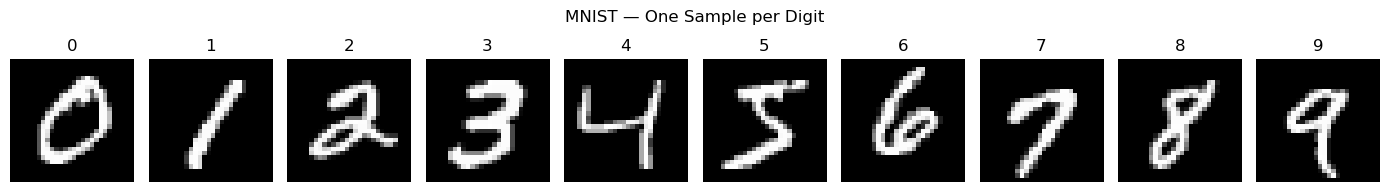

In [3]:
# Visualise one example of each digit (0–9)
fig, axes = plt.subplots(1, 10, figsize=(14, 2))
fig.suptitle("MNIST — One Sample per Digit", fontsize=12)

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]  # find first image of this digit
    axes[digit].imshow(x_train[idx, :, :, 0], cmap="gray")
    axes[digit].set_title(str(digit))
    axes[digit].axis("off")

plt.tight_layout()
plt.show()

---
# Autoencoders

## What is an Autoencoder?

An autoencoder is a neural network with two parts:
- **Encoder** — compresses the input into a small vector called the **latent vector**
- **Decoder** — reconstructs the original input from that compressed vector

```
Input (784 pixels)  →  ENCODER  →  Latent Vector (16 numbers)  →  DECODER  →  Reconstructed Input
```

The **bottleneck** forces the network to keep only the most important features and discard noise.

| Application | How |
|-------------|-----|
| Dimensionality reduction | 784 pixels → 16 numbers, keeping structure |
| Denoising | Train on noisy input, clean target |
| Anomaly detection | Normal data reconstructs well; anomalies do not |

## Build a Convolutional Autoencoder

We use **Conv2D** layers because they understand spatial structure (nearby pixels relate to each other).  
**`strides=2`** halves the spatial size — like MaxPooling but learnable.  
**`Conv2DTranspose`** does the reverse — doubles the spatial size (upsampling).

In [4]:
LATENT_DIM  = 16          # Size of the bottleneck (compressed representation)
IMAGE_SHAPE = (28, 28, 1)

# ── ENCODER ──────────────────────────────────────────────────────────────────
encoder_input = keras.Input(shape=IMAGE_SHAPE, name="encoder_input")

x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_input)  # 28×28 → 14×14
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)              # 14×14 → 7×7
x = layers.Flatten()(x)                                                                 # 7×7×64 → flat vector
x = layers.Dense(128, activation="relu")(x)
latent = layers.Dense(LATENT_DIM, name="latent")(x)                                    # bottleneck

encoder = Model(encoder_input, latent, name="Encoder")

# ── DECODER ──────────────────────────────────────────────────────────────────
decoder_input = keras.Input(shape=(LATENT_DIM,), name="decoder_input")

x = layers.Dense(7 * 7 * 64, activation="relu")(decoder_input)
x = layers.Reshape((7, 7, 64))(x)                                                       # flat → 3-D
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)      # 7×7 → 14×14
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)      # 14×14 → 28×28
decoder_output = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)  # output: [0,1]

decoder = Model(decoder_input, decoder_output, name="Decoder")

# ── FULL AUTOENCODER: chain encoder → decoder ─────────────────────────────────
ae_in  = keras.Input(shape=IMAGE_SHAPE)
ae_out = decoder(encoder(ae_in))
autoencoder = Model(ae_in, ae_out, name="Autoencoder")

# binary_crossentropy works well for pixels in [0, 1]
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

print(f"Bottleneck : {LATENT_DIM} numbers")
print(f"Input size : {28*28} pixels")
print(f"Compression: {28*28 // LATENT_DIM}:1")
print()
encoder.summary()

Bottleneck : 16 numbers
Input size : 784 pixels
Compression: 49:1



Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 14, 14, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 7, 7, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ latent (Dense)                       │ (None, 16)                  │           2,064 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 422,416 (1.61 MB)

 Trainable params: 422,416 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

##  Train the Autoencoder

> **Key point:** The **target (y) is the same as the input (x)**.  
> The model learns to reproduce its own input through the bottleneck.

In [5]:
# Training on 10,000 samples for 10 epochs — runs in ~1–2 minutes
# input = target  (the model reconstructs its own input)
history_ae = autoencoder.fit(
    x_train_small, x_train_small,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_split=0.1,       # use 10% of training data to monitor val loss
    verbose=1
)
print("\n✓ Autoencoder training complete")

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 196ms/step - loss: 0.4228 - val_loss: 0.2767
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 181ms/step - loss: 0.2652 - val_loss: 0.2592
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - loss: 0.2482 - val_loss: 0.2365
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step - loss: 0.2113 - val_loss: 0.1895
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step - loss: 0.1679 - val_loss: 0.1571
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - loss: 0.1451 - val_loss: 0.1430
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 186ms/step - loss: 0.1330 - val_loss: 0.1327
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 189ms/step - loss: 0.1234 - val_loss: 0.1244
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - loss: 0.1163 - val_loss: 0.1188
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step - loss: 0.1113 - val_loss: 0.1149

✓ Autoencoder training complete


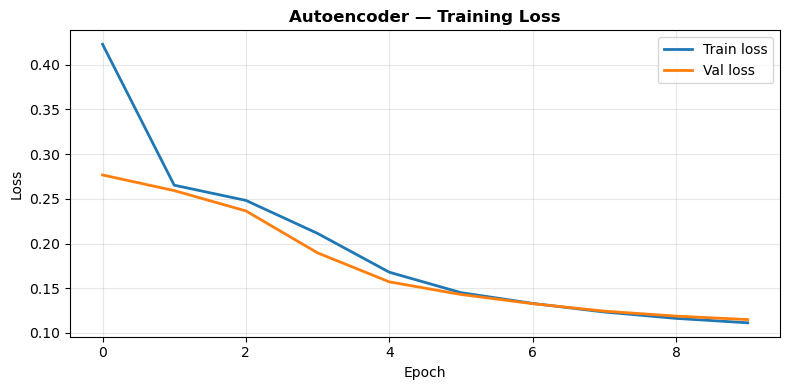

In [6]:
# Plot training curves — always check these to confirm training went well
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_ae.history["loss"],     label="Train loss", linewidth=2)
ax.plot(history_ae.history["val_loss"], label="Val loss",   linewidth=2)
ax.set_title("Autoencoder — Training Loss", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# How to read this chart:
# ✅ HEALTHY     → both lines decrease and stay close together
# ⚠  OVERFITTING → train keeps dropping but val_loss rises
# ⚠  UNDERFITTING → both lines barely move

## Visualise Reconstructions

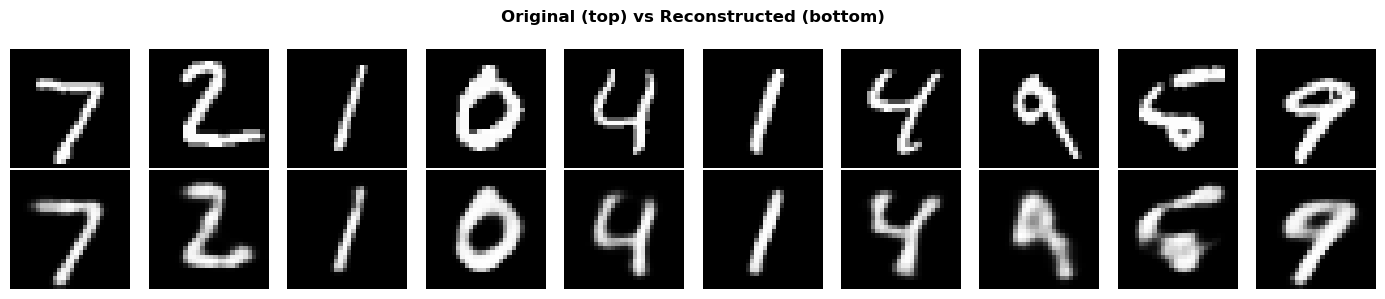

In [7]:
n = 10
reconstructed = autoencoder.predict(x_test[:n], verbose=0)

fig, axes = plt.subplots(2, n, figsize=(14, 3))
fig.suptitle("Original (top) vs Reconstructed (bottom)", fontweight="bold")

for i in range(n):
    axes[0, i].imshow(x_test[i, :, :, 0],       cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(reconstructed[i, :, :, 0], cmap="gray")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

# Reconstructions look similar but slightly blurry — expected.
# The bottleneck discards fine pixel details to fit into 16 numbers.

## Denoising Autoencoder

Train on **noisy input**, target the **clean output**.  
The bottleneck forces the model to ignore noise and keep only meaningful structure.

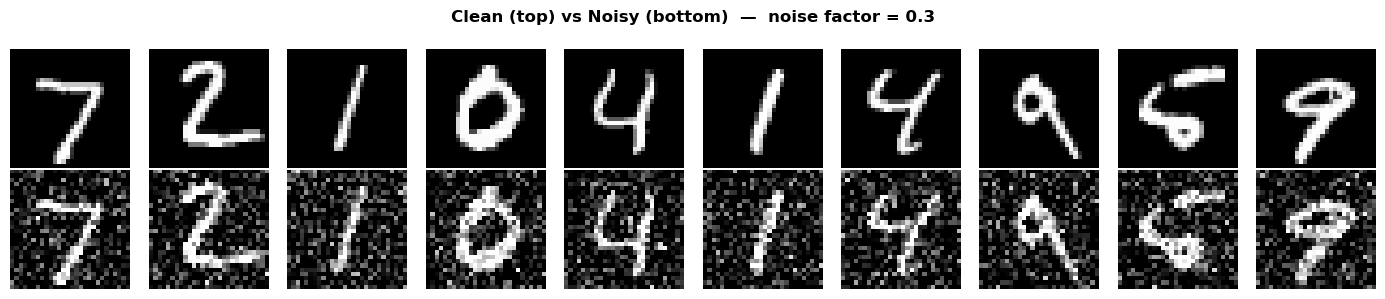

In [8]:
# Add Gaussian noise to the images and clip to stay in [0, 1]
NOISE = 0.3
x_train_noisy = np.clip(x_train_small + NOISE * np.random.randn(*x_train_small.shape).astype("float32"), 0, 1)
x_test_noisy  = np.clip(x_test        + NOISE * np.random.randn(*x_test.shape).astype("float32"),        0, 1)

# Show clean vs noisy side by side
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
fig.suptitle(f"Clean (top) vs Noisy (bottom)  —  noise factor = {NOISE}", fontweight="bold")
for i in range(10):
    axes[0, i].imshow(x_test[i, :, :, 0],       cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(x_test_noisy[i, :, :, 0], cmap="gray")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

In [9]:
# Build a denoising autoencoder — same architecture, different training target
denoising_ae = keras.models.clone_model(autoencoder)
denoising_ae.compile(optimizer="adam", loss="binary_crossentropy")

# input = NOISY image,  target = CLEAN image
denoising_ae.fit(
    x_train_noisy, x_train_small,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_split=0.1,
    verbose=1
)
print("\n✓ Denoising autoencoder trained")

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 182ms/step - loss: 0.4663 - val_loss: 0.2796
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - loss: 0.2700 - val_loss: 0.2683
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 170ms/step - loss: 0.2640 - val_loss: 0.2640
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step - loss: 0.2573 - val_loss: 0.2519
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - loss: 0.2432 - val_loss: 0.2353
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 169ms/step - loss: 0.2105 - val_loss: 0.1897
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 169ms/step - loss: 0.1734 - val_loss: 0.1716
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step - loss: 0.1575 - val_loss: 0.1558
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - loss: 0.1454 - val_loss: 0.1455
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 168ms/step - loss: 0.1366 - val_loss: 0.1387

✓ Denoising autoencoder trained


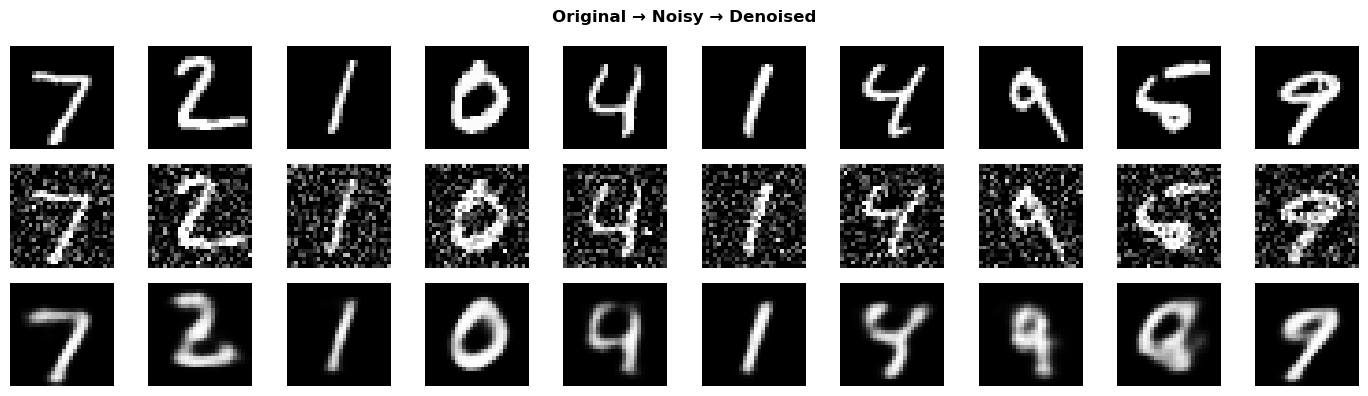

In [10]:
# Visualise: original → noisy → denoised
n = 10
denoised = denoising_ae.predict(x_test_noisy[:n], verbose=0)

fig, axes = plt.subplots(3, n, figsize=(14, 4))
fig.suptitle("Original → Noisy → Denoised", fontweight="bold")

for i in range(n):
    axes[0, i].imshow(x_test[i, :, :, 0],       cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(x_test_noisy[i, :, :, 0], cmap="gray")
    axes[1, i].axis("off")
    axes[2, i].imshow(denoised[i, :, :, 0],      cmap="gray")
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("Original",  fontsize=9)
axes[1, 0].set_ylabel("Noisy",     fontsize=9)
axes[2, 0].set_ylabel("Denoised",  fontsize=9)
plt.tight_layout()
plt.show()

---
# Variational Autoencoders (VAEs)

## Why Not Use a Regular Autoencoder for Generation?

A regular autoencoder maps each image to a **single fixed point** in latent space.  
The space between points is undefined — if you sample a random point, the decoder produces garbage.

**VAEs fix this** by mapping each image to a **probability distribution** (a fuzzy cloud) instead of a single point. The latent space becomes **continuous**, so any point you sample decodes into a meaningful image.

## VAE Architecture


## The Reparameterization Trick

We cannot backpropagate through a random sampling step — it has no gradient.  
**Solution:** sample ε from N(0,1) separately, then compute `z = μ + σ × ε`.  
Now μ and σ are learnable parameters that gradients flow through normally.

## VAE Loss = Reconstruction Loss + KL Divergence

| Term | Job |
|------|-----|
| **Reconstruction Loss** | Make the decoded output look like the input |
| **KL Divergence** | Keep the latent distributions close to N(0,1) so we can sample from it |

In [11]:
# ── Sampling Layer — the reparameterization trick in code ─────────────────────
# z = mu + exp(0.5 * log_var) * epsilon
# exp(0.5 * log_var) converts log-variance back to standard deviation
# epsilon is random noise sampled from N(0,1) — this is the stochastic part

class Sampling(layers.Layer):
    """Reparameterization: z = mu + exp(0.5 * log_var) * epsilon"""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))  # sample from N(0,1)
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

print("Sampling layer defined ✓")

Sampling layer defined ✓


In [12]:
# ── VAE Encoder ───────────────────────────────────────────────────────────────
# Outputs THREE things: z_mean, z_log_var, and the sampled z
# We use LATENT_DIM_VAE = 2 so we can plot and explore the latent space easily

LATENT_DIM_VAE = 2

vae_enc_in = keras.Input(shape=IMAGE_SHAPE, name="vae_enc_input")
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(vae_enc_in)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)

# Two output heads: one for mean, one for log-variance
z_mean    = layers.Dense(LATENT_DIM_VAE, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM_VAE, name="z_log_var")(x)
z         = Sampling(name="z")([z_mean, z_log_var])   # apply reparameterization

vae_encoder = Model(vae_enc_in, [z_mean, z_log_var, z], name="VAE_Encoder")
print("VAE Encoder built ✓")
vae_encoder.summary()


VAE Encoder built ✓


Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ vae_enc_input (InputLayer)    │ (None, 28, 28, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 14, 14, 32)        │             320 │ vae_enc_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 7, 7, 64)          │          18,496 │ conv2d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_1 (Flatten)           │ (None, 3136)              │               0 │ conv2d_3[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 128)               │         401,536 │ flatten_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_mean (Dense)                │ (None, 2)                 │             258 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_log_var (Dense)             │ (None, 2)                 │             258 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z (Sampling)                  │ (None, 2)                 │               0 │ z_mean[0][0],              │
│                               │                           │                 │ z_log_var[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 420,868 (1.61 MB)

 Trainable params: 420,868 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ── VAE Decoder ───────────────────────────────────────────────────────────────
# Takes a point z from latent space and generates an image.
# During generation we skip the encoder and feed random z directly here.

vae_dec_in = keras.Input(shape=(LATENT_DIM_VAE,), name="vae_dec_input")
x = layers.Dense(7 * 7 * 64, activation="relu")(vae_dec_in)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
vae_dec_out = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)

vae_decoder = Model(vae_dec_in, vae_dec_out, name="VAE_Decoder")
print("VAE Decoder built ✓")
vae_decoder.summary()

VAE Decoder built ✓


Model: "VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vae_dec_input (InputLayer)           │ (None, 2)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3136)                │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_1 (Reshape)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_3 (Conv2DTranspose) │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_4 (Conv2DTranspose) │ (None, 28, 28, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_5 (Conv2DTranspose) │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# ── Full VAE Model with Custom Loss ───────────────────────────────────────────
# We subclass keras.Model so we can override train_step() to include the KL loss

class VAE(keras.Model):

    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        # Metrics displayed during training
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker    = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction loss: how well does the output match the input?
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )

            # KL Divergence: how far is the learned distribution from N(0,1)?
            # Formula: -0.5 * sum(1 + log_var - mu² - exp(log_var))
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )

            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

print("VAE class defined ✓")

VAE class defined ✓


In [15]:
# Train the VAE — 10 epochs on 10,000 samples, runs in ~2–3 minutes
vae = VAE(vae_encoder, vae_decoder, name="VAE")
vae.compile(optimizer=keras.optimizers.Adam(1e-3))

history_vae = vae.fit(
    x_train_small,
    epochs=10,
    batch_size=256,
    shuffle=True,
    verbose=1
)
print("\n✓ VAE training complete")

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 176ms/step - kl_loss: 5.0044 - recon_loss: 352.8525 - total_loss: 357.8570
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - kl_loss: 3.4775 - recon_loss: 209.0964 - total_loss: 212.5739
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step - kl_loss: 3.0488 - recon_loss: 195.1990 - total_loss: 198.2478
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 162ms/step - kl_loss: 2.7778 - recon_loss: 192.0468 - total_loss: 194.8246
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 168ms/step - kl_loss: 3.4496 - recon_loss: 185.5623 - total_loss: 189.0118
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 174ms/step - kl_loss: 3.9473 - recon_loss: 180.3934 - total_loss: 184.3407
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 187ms/step - kl_loss: 4.0293 - recon_loss: 178.3246 - total_loss: 182.3539
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 168ms/step - kl_loss: 4.1368 - recon_loss: 176.3378 - total_loss: 180.4746
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 164ms/step - kl_loss: 4.2836 

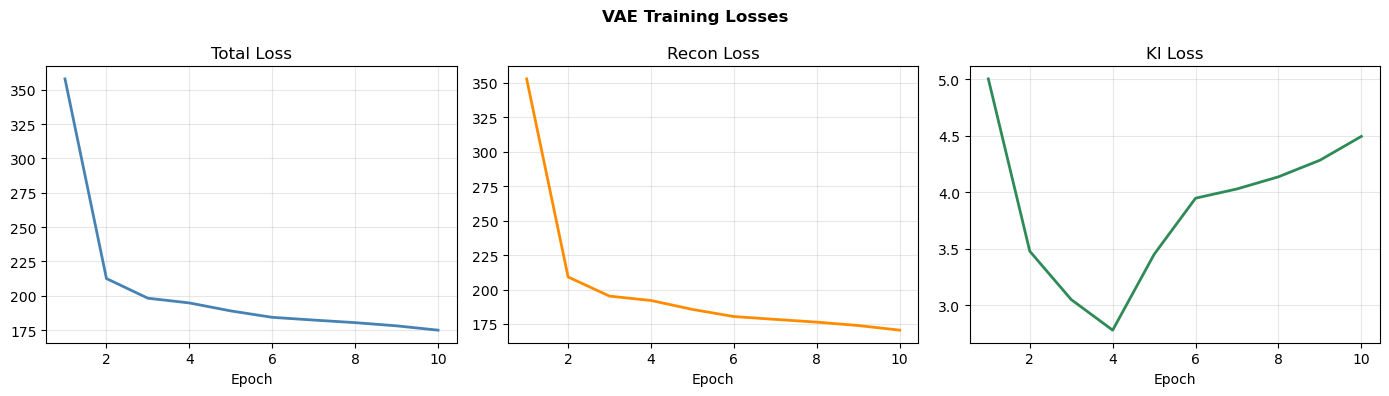

In [16]:
# Plot all three VAE losses — total, reconstruction, and KL divergence
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("VAE Training Losses", fontweight="bold")

for ax, key, color in zip(
    axes,
    ["total_loss", "recon_loss", "kl_loss"],
    ["steelblue",  "darkorange", "seagreen"]
):
    vals = history_vae.history[key]
    ax.plot(range(1, len(vals)+1), vals, color=color, linewidth=2)
    ax.set_title(key.replace("_", " ").title())
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Total loss    → should steadily decrease
# Recon loss    → model gets better at rebuilding images
# KL divergence → rises then stabilises as the latent space organises itself

## Visualise the 2D Latent Space

Because `LATENT_DIM_VAE = 2`, we can plot the entire latent space as a 2D scatter chart.

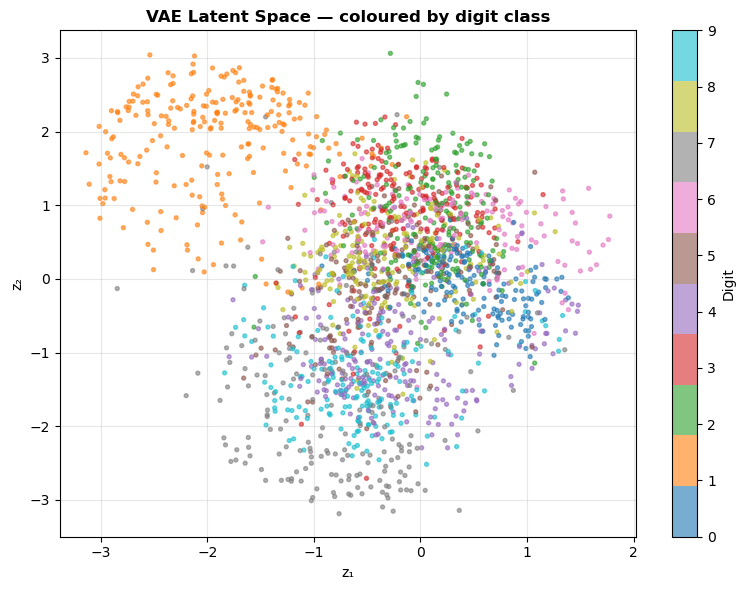

In [17]:
# Encode 2,000 test images and plot their latent positions
z_mean_test, _, _ = vae_encoder.predict(x_test[:2000], verbose=0)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(z_mean_test[:, 0], z_mean_test[:, 1],
                c=y_test[:2000], cmap="tab10", alpha=0.6, s=8)
plt.colorbar(sc, ax=ax, label="Digit", ticks=range(10))
ax.set_title("VAE Latent Space — coloured by digit class", fontweight="bold")
ax.set_xlabel("z₁")
ax.set_ylabel("z₂")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Key observation: the latent space is CONTINUOUS.
# Different digit clusters overlap smoothly — this is what makes generation possible.
# A regular autoencoder would have disconnected, scattered points with gaps in between.

## Generate New Images by Sampling

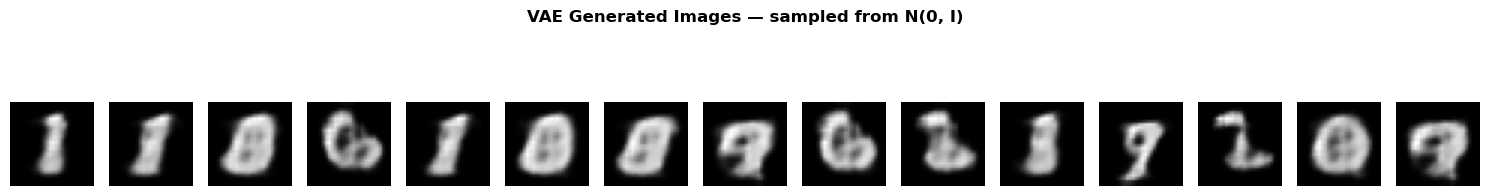

In [18]:
# Sample random points from N(0,1) and decode each one into an image
# The KL loss during training made the latent space look like N(0,1),
# so sampling from N(0,1) always gives a valid latent vector

random_z  = np.random.randn(15, LATENT_DIM_VAE).astype("float32")
generated = vae_decoder.predict(random_z, verbose=0)

fig, axes = plt.subplots(1, 15, figsize=(15, 2.5))
fig.suptitle("VAE Generated Images — sampled from N(0, I)", fontweight="bold")
for i, ax in enumerate(axes):
    ax.imshow(generated[i, :, :, 0], cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.show()

# These images were never in the training data — the VAE generated them.

## Latent Space Interpolation

We can smoothly morph one digit into another by **interpolating between two points in latent space**.

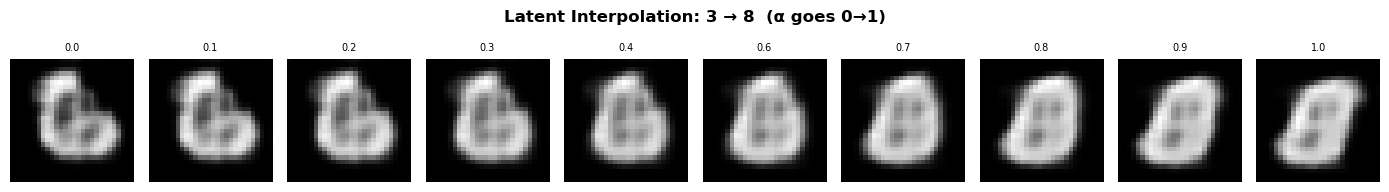

In [19]:
def get_digit(digit, idx=0):
    """Return one example of the given digit from the test set."""
    pos = np.where(y_test == digit)[0][idx]
    return x_test[pos][np.newaxis, ...]

# Choose the two digits to morph between (change these to try different pairs)
DIGIT_A, DIGIT_B = 3, 8

img_a = get_digit(DIGIT_A)
img_b = get_digit(DIGIT_B)

# Encode each image to its latent mean (no randomness)
z_a, _, _ = vae_encoder.predict(img_a, verbose=0)
z_b, _, _ = vae_encoder.predict(img_b, verbose=0)

# Linearly interpolate between z_a and z_b in 10 steps
steps     = 10
alphas    = np.linspace(0, 1, steps)
z_path    = np.array([z_a * (1-a) + z_b * a for a in alphas])[:, 0, :]
path_imgs = vae_decoder.predict(z_path, verbose=0)

fig, axes = plt.subplots(1, steps, figsize=(14, 2))
fig.suptitle(f"Latent Interpolation: {DIGIT_A} → {DIGIT_B}  (α goes 0→1)", fontweight="bold")
for i, ax in enumerate(axes):
    ax.imshow(path_imgs[i, :, :, 0], cmap="gray")
    ax.set_title(f"{alphas[i]:.1f}", fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Each image is a smooth blend of the two digits.
# This only works because the VAE latent space is continuous.

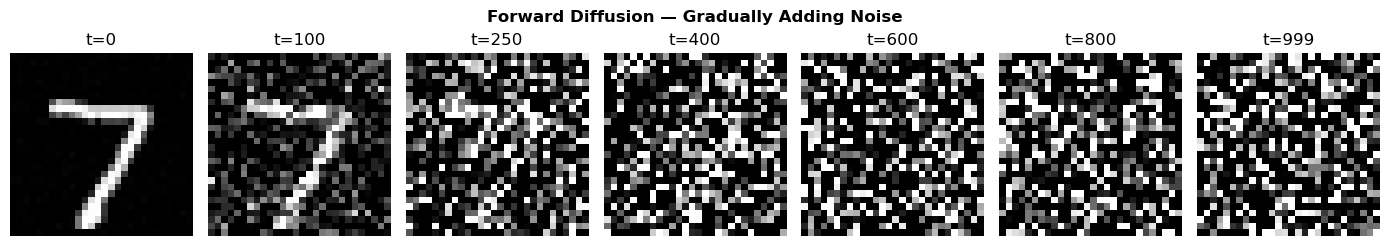

In [20]:
# ── Visualise the Forward Process (no training needed) ────────────────────────
# This shows exactly what the model has to learn to reverse.

T = 1000    # Total diffusion steps

# Noise schedule: how much noise to add at each step
# beta is small early (gentle) and larger later (aggressive)
betas          = np.linspace(1e-4, 0.02, T, dtype=np.float32)
alphas_cumprod = np.cumprod(1.0 - betas)  # ᾱ_t: how much signal remains at step t

def add_noise(x0, t):
    """
    Jump directly to noise level t — no need to simulate all steps.
    Formula:  x_t = sqrt(ᾱ_t) * x_0  +  sqrt(1 - ᾱ_t) * epsilon
    This is the 'nice property' of DDPM — any step can be computed directly.
    """
    eps = np.random.randn(*x0.shape).astype("float32")
    return np.sqrt(alphas_cumprod[t]) * x0 + np.sqrt(1 - alphas_cumprod[t]) * eps

sample = x_test[0]   # one clean digit image

fig, axes = plt.subplots(1, 7, figsize=(14, 2.5))
fig.suptitle("Forward Diffusion — Gradually Adding Noise", fontweight="bold")

for ax, t in zip(axes, [0, 100, 250, 400, 600, 800, 999]):
    noisy = add_noise(sample, t)
    ax.imshow(np.clip(noisy[:, :, 0], 0, 1), cmap="gray")
    ax.set_title(f"t={t}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# By t=999 the original image is completely destroyed.
# The diffusion model learns to go from right to left — pure noise → clean image.

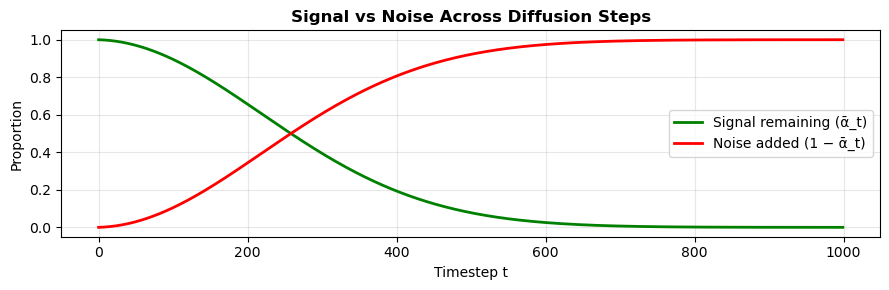

In [21]:
# ── Signal vs Noise Chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(range(T), alphas_cumprod,       label="Signal remaining (ᾱ_t)", linewidth=2, color="green")
ax.plot(range(T), 1 - alphas_cumprod,   label="Noise added (1 − ᾱ_t)", linewidth=2, color="red")
ax.set_title("Signal vs Noise Across Diffusion Steps", fontweight="bold")
ax.set_xlabel("Timestep t")
ax.set_ylabel("Proportion")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Green = how much original image is still visible
# Red   = how much noise has been mixed in
# The model must learn to recover the green from the red, at every single step

## The U-Net Architecture (Concept)

The neural network used inside diffusion models is called a **U-Net**.

```
Noisy image x_t  ──►  U-Net  ──►  Predicted noise ε
Timestep t       ──►  (also input)
```

The U-Net has three parts:
- **Encoder** — downsamples the image, extracts features
- **Bottleneck** — processes the most compressed representation
- **Decoder** — upsamples back to original size
- **Skip connections** — connect encoder layers to decoder layers to preserve detail

The timestep `t` is embedded as a vector and added at each layer so the network knows how noisy its input is.

>  **Note:** Training a full diffusion model from scratch takes hours on a GPU.  
> The cell below shows the architecture and a single forward pass — no long training.

In [22]:
# ── Build and show the U-Net architecture ─────────────────────────────────────
# This is the same architecture used in production diffusion models.
# We just show the structure — no training (would take too long on CPU).

def build_unet(img_size=28, channels=1, time_dim=32):
    # Input 1: the noisy image at step t
    img_input  = keras.Input(shape=(img_size, img_size, channels), name="noisy_image")
    # Input 2: the timestep t normalised to [0, 1]
    time_input = keras.Input(shape=(1,), name="timestep")

    # Embed timestep into a vector — the model needs to know HOW noisy the input is
    t = layers.Dense(time_dim, activation="swish")(time_input)
    t = layers.Dense(time_dim, activation="swish")(t)
    t = layers.Reshape((1, 1, time_dim))(t)
    t = layers.UpSampling2D(size=(img_size, img_size))(t)  # broadcast across image

    x = layers.Concatenate()([img_input, t])   # combine image + time info

    # Encoder (downsampling path)
    skip1 = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x     = layers.Conv2D(32, 3, padding="same", activation="relu", strides=2)(skip1)  # 28→14

    skip2 = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x     = layers.Conv2D(64, 3, padding="same", activation="relu", strides=2)(skip2)  # 14→7

    # Bottleneck
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)

    # Decoder (upsampling path) with skip connections
    x = layers.Conv2DTranspose(64, 3, padding="same", activation="relu", strides=2)(x)  # 7→14
    x = layers.Concatenate()([x, skip2])   # skip connection: bring back encoder features
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)

    x = layers.Conv2DTranspose(32, 3, padding="same", activation="relu", strides=2)(x)  # 14→28
    x = layers.Concatenate()([x, skip1])   # skip connection
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)

    # Output: predicted noise — same shape as input
    out = layers.Conv2D(channels, 1, padding="same", name="predicted_noise")(x)

    return Model([img_input, time_input], out, name="Denoising_UNet")


unet = build_unet()
print(f"U-Net parameters : {unet.count_params():,}")
print("\nInputs  : noisy image  +  timestep")
print("Output  : predicted noise (same shape as image)")
print()

# ── Demo: one forward pass (no training) ──────────────────────────────────────
# Show that the network can accept the right inputs and produce the right output shape
dummy_img  = np.random.randn(1, 28, 28, 1).astype("float32")
dummy_time = np.array([[0.5]], dtype="float32")    # timestep = 500/1000
dummy_out  = unet([dummy_img, dummy_time])

print(f"Input  shape : {dummy_img.shape}")
print(f"Output shape : {dummy_out.shape}  ← same as input (predicted noise)")
print("\nU-Net architecture verified ✓")

U-Net parameters : 333,729

Inputs  : noisy image  +  timestep
Output  : predicted noise (same shape as image)

Input  shape : (1, 28, 28, 1)
Output shape : (1, 28, 28, 1)  ← same as input (predicted noise)

U-Net architecture verified ✓


## Stable Diffusion: How It Connects

Stable Diffusion applies the same DDPM idea with two key improvements:

1. **Latent diffusion** — runs diffusion in a VAE's latent space (64×64) instead of pixel space (512×512). This is 8× cheaper in compute.
2. **Text conditioning** — a CLIP text encoder converts your prompt into a vector. The U-Net uses this vector at every denoising step to guide the image toward your description.

```
Your text prompt  →  CLIP Text Encoder  →  Text embedding
                                                  ↓
Random noise  →  Latent U-Net (50 steps)  →  Clean latent  →  VAE Decoder  →  Final image
```

#  Evaluation Metrics

Standard accuracy does not work for generative models — there is no single correct output.  
We use metrics that measure **quality** and **diversity** of generated images.

| Metric | What It Measures | Direction |
|--------|------------------|-----------|
| **FID** (Fréchet Inception Distance) | How close generated images are to real images statistically | Lower = better |
| **IS** (Inception Score) | Quality + diversity of generated images | Higher = better |
| **MSE** | Pixel-level reconstruction error | Lower = better |
| **PSNR** | Signal quality vs noise in reconstruction | Higher = better (>30 dB is good) |

**FID** is the most widely used. It passes both real and generated images through InceptionV3 and compares the statistics of their feature vectors.

In [23]:
# ── Compute MSE and PSNR for our autoencoder ──────────────────────────────────

def compute_mse(original, recon):
    """Mean Squared Error — lower is better."""
    return float(np.mean((original - recon) ** 2))

def compute_psnr(original, recon, max_val=1.0):
    """
    Peak Signal-to-Noise Ratio — higher is better.
    Above 30 dB is considered good quality for reconstruction.
    """
    m = compute_mse(original, recon)
    return float(20 * np.log10(max_val / (np.sqrt(m) + 1e-10)))

N = 200   # evaluate on 200 test images — fast
ae_recon  = autoencoder.predict(x_test[:N], verbose=0)
vae_recon = vae(x_test[:N]).numpy()

print("RECONSTRUCTION QUALITY")
print("═" * 42)
print(f"{'Model':<20} {'MSE':>8}  {'PSNR (dB)':>10}")
print("─" * 42)
print(f"{'Autoencoder':<20} {compute_mse(x_test[:N], ae_recon):>8.5f}  {compute_psnr(x_test[:N], ae_recon):>10.2f}")
print(f"{'VAE':<20} {compute_mse(x_test[:N], vae_recon):>8.5f}  {compute_psnr(x_test[:N], vae_recon):>10.2f}")
print("─" * 42)
print()
print("Note: The VAE typically has higher MSE than the regular autoencoder.")
print("This is the quality/generation trade-off — the KL loss makes the latent")
print("space generative and smooth, but slightly less precise per image.")

RECONSTRUCTION QUALITY
══════════════════════════════════════════
Model                     MSE   PSNR (dB)
──────────────────────────────────────────
Autoencoder           0.01580       18.01
VAE                   0.05266       12.79
──────────────────────────────────────────

Note: The VAE typically has higher MSE than the regular autoencoder.
This is the quality/generation trade-off — the KL loss makes the latent
space generative and smooth, but slightly less precise per image.


# GANs vs VAEs vs Diffusion Models

In [24]:
print("""
╔══════════════════╦═══════════════════════╦═══════════════════════╦═══════════════════════╗
║                  ║         GANs          ║         VAEs          ║   Diffusion Models    ║
╠══════════════════╬═══════════════════════╬═══════════════════════╬═══════════════════════╣
║ Core idea        ║ Generator vs          ║ Learn a probabilistic ║ Reverse a noising     ║
║                  ║ Discriminator game    ║ latent space          ║ process step-by-step  ║
╠══════════════════╬═══════════════════════╬═══════════════════════╬═══════════════════════╣
║ Latent space     ║ Implicit              ║ Explicit, structured  ║ Implicit              ║
╠══════════════════╬═══════════════════════╬═══════════════════════╬═══════════════════════╣
║ Training         ║ Unstable              ║ Stable                ║ Very stable           ║
║ stability        ║ (mode collapse risk)  ║                       ║                       ║
╠══════════════════╬═══════════════════════╬═══════════════════════╬═══════════════════════╣
║ Output quality   ║ Sharp, artefacts      ║ Slightly blurry       ║ Best (state-of-art)   ║
╠══════════════════╬═══════════════════════╬═══════════════════════╬═══════════════════════╣
║ Generation speed ║ Very fast             ║ Very fast             ║ Slow (many steps)     ║
╠══════════════════╬═══════════════════════╬═══════════════════════╬═══════════════════════╣
║ Text control     ║ Limited               ║ Limited               ║ Excellent             ║
║                  ║                       ║                       ║ (SD, DALL-E 3)        ║
╠══════════════════╬═══════════════════════╬═══════════════════════╬═══════════════════════╣
║ Best for         ║ Fast synthesis,       ║ Compression, anomaly  ║ Text-to-image,        ║
║                  ║ face generation       ║ detection, editing    ║ highest quality       ║
╠══════════════════╬═══════════════════════╬═══════════════════════╬═══════════════════════╣
║ Famous examples  ║ StyleGAN, CycleGAN    ║ β-VAE, VQ-VAE         ║ Stable Diffusion,     ║
║                  ║                       ║                       ║ DALL-E 3, Midjourney  ║
╚══════════════════╩═══════════════════════╩═══════════════════════╩═══════════════════════╝

RULE OF THUMB:
  Use GANs       → when speed matters most
  Use VAEs       → when you need an explicit, editable latent space
  Use Diffusion  → when you need the best image quality and text control
""")


╔══════════════════╦═══════════════════════╦═══════════════════════╦═══════════════════════╗
║                  ║         GANs          ║         VAEs          ║   Diffusion Models    ║
╠══════════════════╬═══════════════════════╬═══════════════════════╬═══════════════════════╣
║ Core idea        ║ Generator vs          ║ Learn a probabilistic ║ Reverse a noising     ║
║                  ║ Discriminator game    ║ latent space          ║ process step-by-step  ║
╠══════════════════╬═══════════════════════╬═══════════════════════╬═══════════════════════╣
║ Latent space     ║ Implicit              ║ Explicit, structured  ║ Implicit              ║
╠══════════════════╬═══════════════════════╬═══════════════════════╬═══════════════════════╣
║ Training         ║ Unstable              ║ Stable                ║ Very stable           ║
║ stability        ║ (mode collapse risk)  ║                       ║                       ║
╠══════════════════╬═══════════════════════╬═══════════════════════╬═